In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

#To see all the columns for a better EDA
pd.set_option('display.max_columns', None) 
# Apply consistent visual 
sns.set_theme(style='darkgrid', palette='muted') 
# Default plot settigs
plt.rcParams.update({ 
    "figure.dpi" : 150,
    "axes.titlesize" : 13,
    "axes.labelsize" : 12,
    "axes.titleweight" : "bold",
})

In [2]:
games = pd.read_csv('../data/processed/games_clean.csv', dtype={'appid': str})

rev_agg = pd.read_csv('../data/processed/reviews_agg.csv', dtype={'app_id': str})

print(f'Games: {games.shape}')
print(f'Reviews agg: {rev_agg.shape}')

Games: (124146, 35)
Reviews agg: (332, 5)


In [3]:
games['total_reviews'] = games['positive'] + games['negative'] # get total reviews
games['positive_rate'] = np.where( # get the positive rate of games
    games['total_reviews'] > 0,    # where it has at least 1 reivew
    games['positive'] / games['total_reviews'], 
    np.nan
)

games_reviewed = games[games['total_reviews'] >= 10].copy()
print(f'Games with >= 10 reviews: {len(games_reviewed):,} / {len(games):,}')

print(f'\nPositive rate describe:')
print(games_reviewed['positive_rate'].describe())

print(f'\nTop 5 by positive:')
print(games_reviewed[['name','positive','negative','positive_rate']]
      .sort_values('positive', ascending=False).head())

Games with >= 10 reviews: 56,657 / 124,146

Positive rate describe:
count    56657.000000
mean         0.772230
std          0.178924
min          0.000000
25%          0.672727
50%          0.812500
75%          0.910180
max          1.000000
Name: positive_rate, dtype: float64

Top 5 by positive:
                            name  positive  negative  positive_rate
45509           Counter-Strike 2   7642084   1173003       0.866932
4193                      Dota 2   2037143    461826       0.815193
59122  Grand Theft Auto V Legacy   1739980    250576       0.874118
8878         PUBG: BATTLEGROUNDS   1520457   1037487       0.594406
10927                   Terraria   1373979     35494       0.974818


---
## **1. Distributions**

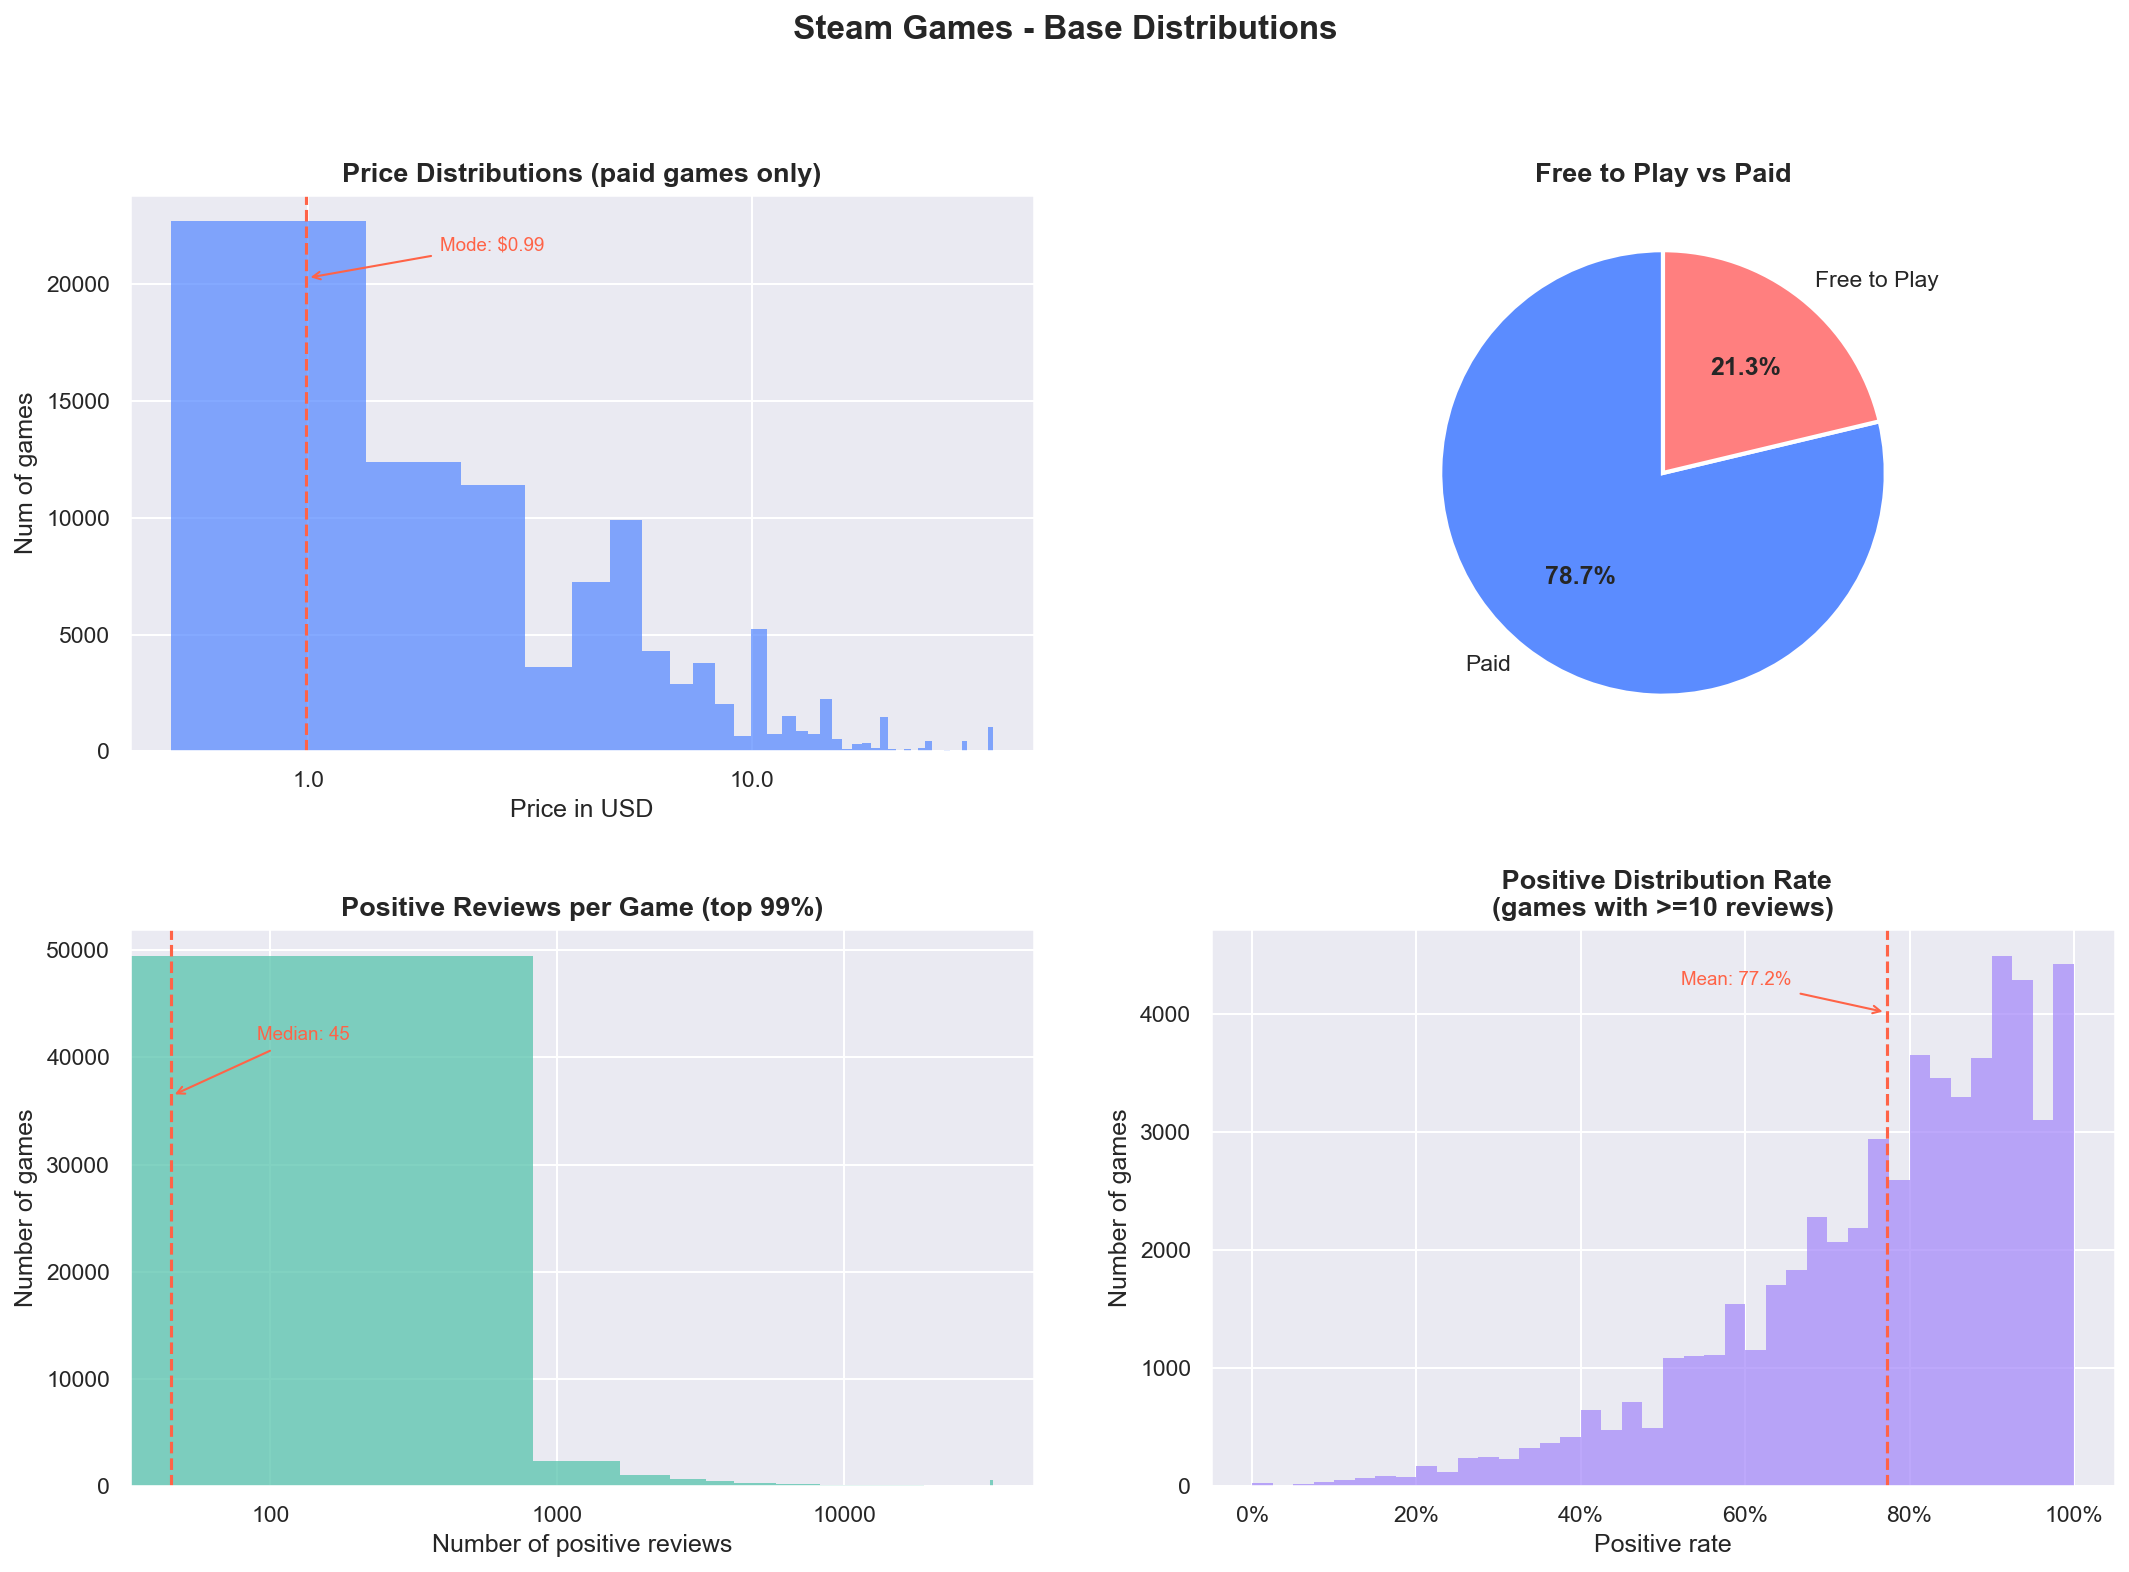

In [4]:
#Distribution base graphs

fig, axes = plt.subplots(2, 2, figsize=(15, 11))
fig.suptitle(
    "Steam Games - Base Distributions", fontsize=16, fontweight="bold")

# Plot 1: Price distribution (paid games only, log scale) 

ax1 = axes[0, 0]

# Only paid games
paid = games.loc[games['price'] > 0, 'price']

# Remove extreme outliers (top 1%)
paid = paid.clip(upper=paid.quantile(0.99))

# Histogram
sns.histplot(paid, bins=40, ax=ax1, color='#5B8CFF', edgecolor='none')

# Log scale
ax1.set_xscale("log")

# IMPORTANT:
# Show real values instead of log/pow
ax1.xaxis.set_major_formatter(mticker.ScalarFormatter())
ax1.xaxis.set_minor_formatter(mticker.NullFormatter())

# Labels
ax1.set_title("Price Distributions (paid games only)")
ax1.set_xlabel("Price in USD")
ax1.set_ylabel("Num of games")

# Mode
mode_price = paid.mode()[0]

ax1.axvline(mode_price, color='tomato', linestyle='--', linewidth=1.5)

ax1.annotate(
    f"Mode: ${mode_price:.2f}",
    xy=(mode_price, ax1.get_ylim()[1] * 0.85), 
    xytext=(mode_price * 2, ax1.get_ylim()[1] * 0.9),
    arrowprops=dict(arrowstyle="->", color="tomato"),
    color="tomato",
    fontsize=9
)

# Plot 2: Free to Play vs Paid 

ax2 = axes[0, 1]

f2p_counts = pd.Series(
    np.where(games['price'] == 0, 'Free to Play', 'Paid')
).value_counts()

wedges, texts, autotexts = ax2.pie(
    f2p_counts,
    labels=f2p_counts.index,
    autopct='%1.1f%%', # format: 70 -> 70.0%
    colors=["#5B8CFF", "#FF7F7F"],
    startangle=90, # start pie at top or 12pm
    wedgeprops=dict(edgecolor='white', linewidth=2) # to each segment or slice
)

for t in autotexts:
    t.set_fontsize(12)
    t.set_fontweight("bold")

ax2.set_title("Free to Play vs Paid")

# Plot 3: Positive reviews distribution (top 99%)

ax3 = axes[1, 0]

# Filter games with at least 1 positive review 
positive_reviews = games_reviewed['positive']

# Clip to remove extreme outliers
positive_reviews = positive_reviews.clip( upper=positive_reviews.quantile(0.99))

sns.histplot(positive_reviews, bins=40, ax=ax3, color='#57C4AD', edgecolor='none')

# Log scale
ax3.set_xscale("log")

# Show nums instead of log/pow 
ax3.xaxis.set_major_formatter(mticker.ScalarFormatter())
ax3.xaxis.set_minor_formatter(mticker.NullFormatter())

ax3.set_title("Positive Reviews per Game (top 99%)")
ax3.set_xlabel("Number of positive reviews")
ax3.set_ylabel("Number of games")

# Median
median_positive = positive_reviews.median()

ax3.axvline(median_positive, color='tomato', linestyle='--', linewidth=1.5)

ax3.annotate(
    f"Median: {int(median_positive):,}",
    xy=(median_positive, ax3.get_ylim()[1] * 0.7), # Point the arrow near the mode line
    xytext=(median_positive * 2, ax3.get_ylim()[1] * 0.8), # Position the label away from the line
    arrowprops=dict(arrowstyle="->", color="tomato"),
    color="tomato",
    fontsize=9
)

# Plot 4: Positive rate distribution 

ax4 = axes[1, 1]

# IMPORTANT:
# Filter valid values
positive_rate = games_reviewed['positive_rate'].dropna()

sns.histplot(positive_rate, bins=40, ax=ax4, color='#A78BFA', edgecolor='none')
ax4.xaxis.set_major_formatter(mticker.PercentFormatter(xmax=1)) # Percentage(%) format in X 
ax4.set_title(" Positive Distribution Rate\n(games with >=10 reviews)")
ax4.set_xlabel("Positive rate")
ax4.set_ylabel("Number of games")

# Mean
mean_rate = positive_rate.mean()

ax4.axvline(mean_rate, color='tomato', linestyle='--', linewidth=1.5)
ax4.annotate(
    f"Mean: {mean_rate:.1%}",
    xy=(mean_rate, ax4.get_ylim()[1] * 0.85),
    xytext=(mean_rate - 0.25, ax4.get_ylim()[1] * 0.9),
    arrowprops=dict(arrowstyle="->", color="tomato"),
    color="tomato",
    fontsize=9
)

# FINAL AJUSTSMENTS

plt.tight_layout(pad=3)
plt.savefig('../images/01_distributions.png', bbox_inches='tight', dpi=150)
plt.show() 

---
## **2. Temporal Trends**

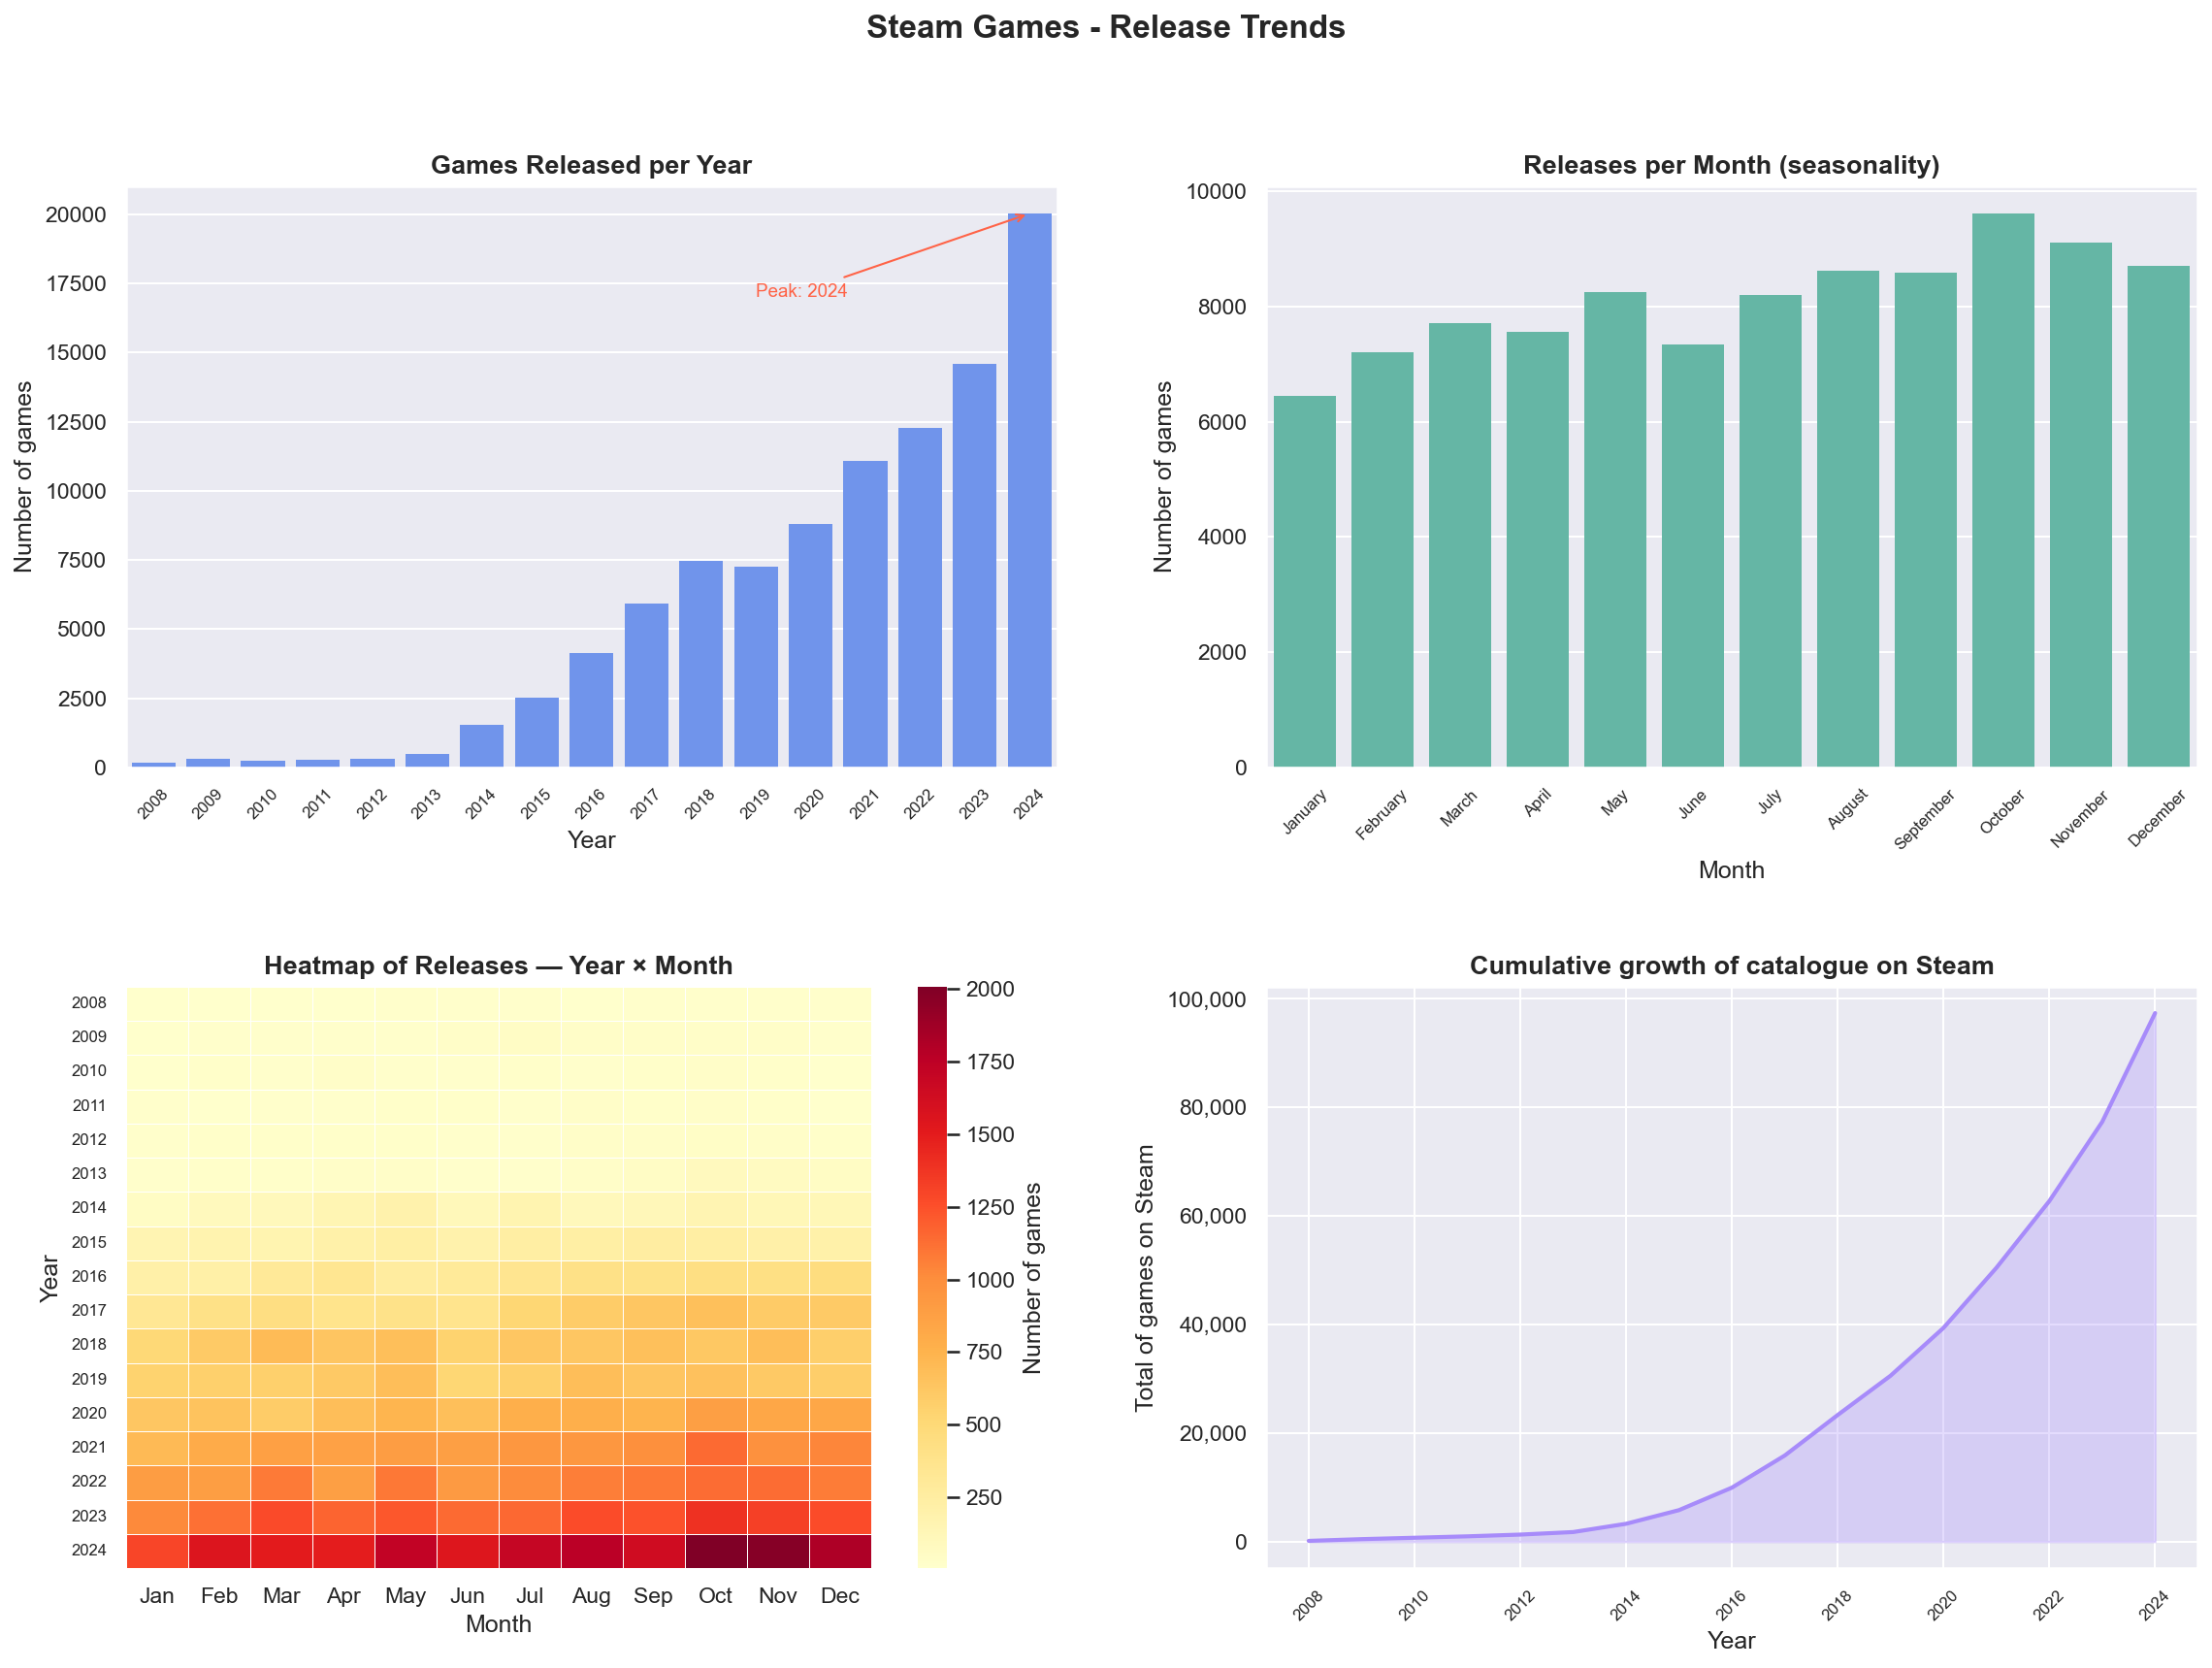

In [7]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Steam Games - Release Trends', fontsize=16, fontweight='bold')

#Filter valid years and discard nulls, future and very old years(unc years)
games_time = games[(games['release_year'] >= 2008) & (games['release_year'] <= 2024)].copy()


# Plot 1: Releases per year

ax1 = axes[0, 0]

releases_year = games_time.groupby('release_year').size().reset_index(name='count')

sns.barplot(data=releases_year, x='release_year', y='count',
            ax=ax1, color='#5B8CFF', edgecolor='none')
ax1.set_title("Games Released per Year")
ax1.set_xlabel("Year")
ax1.set_ylabel("Number of games")

# Rotate X axis labels for better readability
ax1.tick_params(axis='x', rotation=45, labelsize=8)

# Max peak
peak_year = releases_year.loc[releases_year['count'].idxmax()]
peak_x = releases_year.index[releases_year['release_year'] == peak_year['release_year']][0]
ax1.annotate(f"Peak: {int(peak_year['release_year'])}",
             xy=(peak_x, peak_year['count']),
             xytext=(peak_x - 5, peak_year['count'] * 0.85),
             arrowprops=dict(arrowstyle='->', color='tomato'),
             color='tomato', fontsize=9)

# Plot 2: Releases per month (seasonality)

ax2 = axes[0, 1]

month_order = ['January','February','March','April','May','June',
               'July','August','September','October','November','December']

releases_month = (
    games_time.groupby('release_month_name')
    .size()
    .reindex(month_order)
    .reset_index(name='count')
)

sns.barplot(data=releases_month, x='release_month_name', y='count',
            ax=ax2, color='#57C4AD', edgecolor='none')

ax2.set_title("Releases per Month (seasonality)")
ax2.set_xlabel("Month")
ax2.set_ylabel("Number of games")
ax2.tick_params(axis='x', rotation=45, labelsize=8)


# Plot 3: Heatmap year x month

ax3 = axes[1, 0]

# Pivot: rows = year, columns = months
heatmap_data = (
    games_time.groupby(['release_year', 'release_month'])
    .size()
    .unstack(fill_value=0)
)

# Rename columns to month names 
heatmap_data.columns = ['Jan','Feb','Mar','Apr','May','Jun',
                        'Jul','Aug','Sep','Oct','Nov','Dec']

sns.heatmap(heatmap_data, ax=ax3, cmap='YlOrRd',
            linewidths=0.3, linecolor='white',
            cbar_kws={'label': 'Number of games'})

ax3.set_title("Heatmap of Releases — Year × Month")
ax3.set_xlabel("Month")
ax3.set_ylabel("Year")
ax3.tick_params(axis='y', labelsize=8)

# Plot 4: Cumulative catalog growth

ax4 = axes[1, 1]
# Create a copy of the dataset and compute cumulative sum of game releases
cumulative = releases_year.copy()
cumulative['cumulative'] = cumulative['count'].cumsum()

ax4.fill_between(cumulative['release_year'], cumulative['cumulative'],
                 alpha=0.3, color='#A78BFA')
ax4.plot(cumulative['release_year'], cumulative['cumulative'],
         color='#A78BFA', linewidth=2)

ax4.set_title("Cumulative growth of catalogue on Steam")
ax4.set_xlabel("Year")
ax4.set_ylabel("Total of games on Steam")

# Format Y with delimiter of thousands
ax4.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
# Rotate X axis labels for better readability
ax4.tick_params(axis='x', rotation=45, labelsize=8)

# FINAL AJUSTSMENTS 

plt.tight_layout(pad=3)
plt.savefig('../images/02_temp_tendencies.png', bbox_inches='tight', dpi=150)
plt.show() 


In [8]:
print(games['genres'].dtype)
print(games['genres'].head(10))
print(f"\nNulls / empty: {(games['genres'] == '').sum()}")

str
0                                NaN
1                          Adventure
2                             Casual
3          Casual, Indie, Simulation
4               Action, Early Access
5                  Action, Adventure
6               Simulation, Strategy
7                      Action, Indie
8                      Casual, Indie
9    Action, Casual, Indie, Strategy
Name: genres, dtype: str

Nulls / empty: 0


---
## **2. Genres**

In [24]:
# Data preparation: explode genres
# Each game may have multiple genres stored as a single string separated by ', '
# dropna is used to remove games with missing genre information
games_genres = games_reviewed.dropna(subset=['genres']).copy()

# Convert genres from a single string into a list
# Example: "Action, RPG" -> ["Action", "RPG"]
games_genres['genre'] = games_genres['genres'].str.split(', ')

# Explode the list so each genre becomes an individual row
# This transforms the dataset into long format 
games_exploded = games_genres.explode('genre')

# Clean whitespace from genre names
games_exploded['genre'] = games_exploded['genre'].str.strip()

# Remove any empty values that may exist after transformation
games_exploded = games_exploded[games_exploded['genre'] != '']

# Summary statistics
print(f"Unique genres: {games_exploded['genre'].nunique()}")

print("\nTop 15 genres by volume:")
print(games_exploded['genre'].value_counts().head(15))

Unique genres: 28

Top 15 genres by volume:
genre
Indie                    40581
Adventure                23959
Action                   23895
Casual                   21803
Simulation               12657
Strategy                 11612
RPG                      10950
Early Access              4672
Free To Play              4231
Sports                    2540
Racing                    2053
Massively Multiplayer     1403
Utilities                  526
Design & Illustration      336
Violent                    282
Name: count, dtype: int64


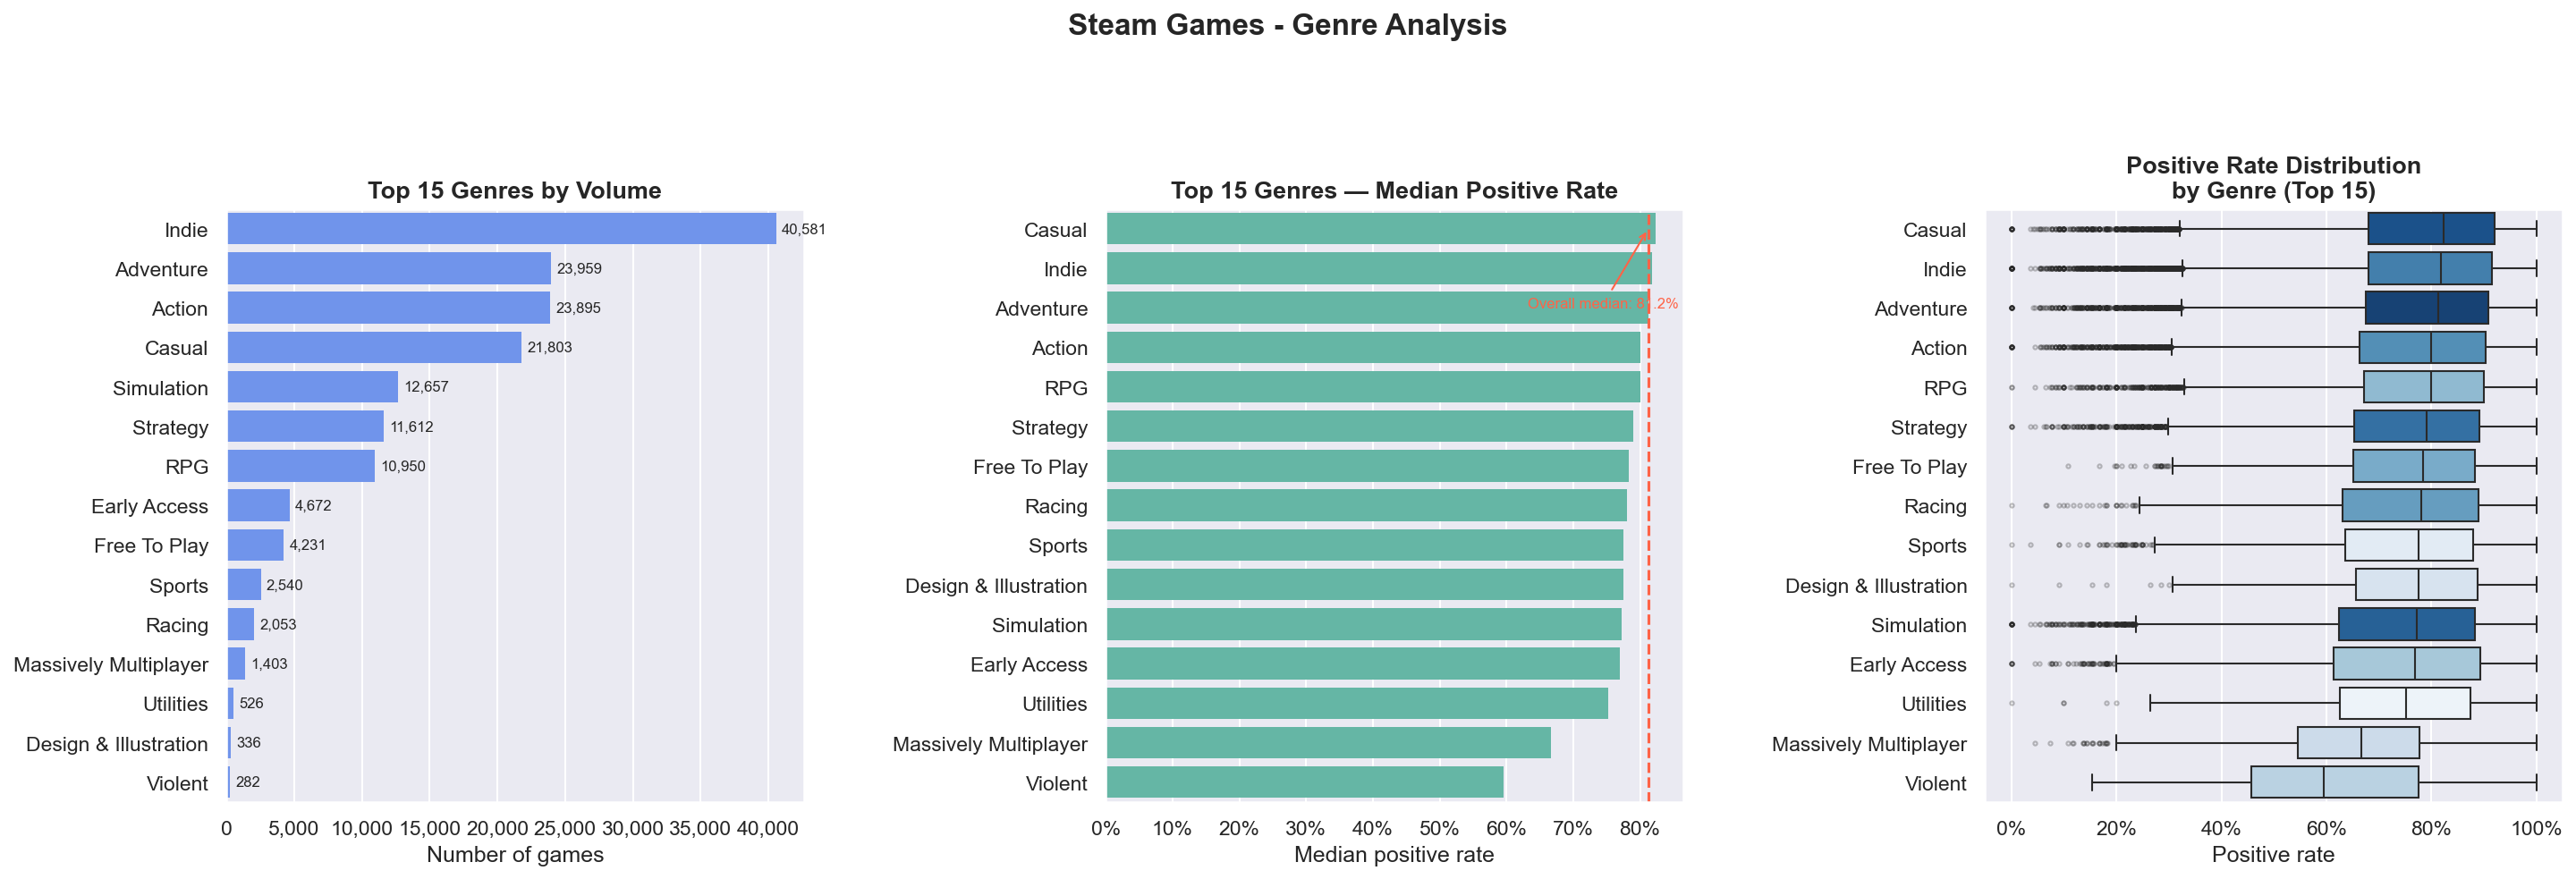

In [32]:
# Create figure
fig, axes = plt.subplots(1, 3, figsize=(20, 7))
fig.suptitle('Steam Games - Genre Analysis', fontsize=16, fontweight='bold')

# Parameters
TOP_N = 15
palette_main = '#5B8CFF'
palette_secondary = '#57C4AD'

# Top genres
top_genres = (games_exploded['genre'].value_counts().head(TOP_N).index)


# Plot 1: Top genres by volume 
ax1 = axes[0]

# Count games per genre and select the top N genres
genre_counts = games_exploded['genre'].value_counts().head(TOP_N).reset_index()
# Rename columns for clarity
genre_counts.columns = ['genre', 'count']

# Barplot for number of games per genre
sns.barplot(data=genre_counts, y='genre', x='count',
            ax=ax1, color='#5B8CFF', edgecolor='none')
ax1.set_title(f'Top {TOP_N} Genres by Volume')
ax1.set_xlabel('Number of games')
ax1.set_ylabel('')
ax1.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}')) # Format x-axis with thousand separators

# Value labels to each bar
ax1.bar_label(
    ax1.containers[0],
    fmt='{:,.0f}',
    padding=3,
    fontsize=8
)

# Plot 2: Median positive rate 
ax2 = axes[1]

# Calculate the median positive rate for the top genres
genre_rating = (
    games_exploded[games_exploded['genre'].isin(top_genres)]
    .groupby('genre')['positive_rate']
    .median()
    .sort_values(ascending=False)
    .reset_index()
)
# Barplot showing median review scores by genre
sns.barplot(data=genre_rating, y='genre', x='positive_rate',
            ax=ax2, color='#57C4AD', edgecolor='none')
ax2.xaxis.set_major_formatter(mticker.PercentFormatter(xmax=1)) # Format x-axis as percentage
ax2.set_title(f'Top {TOP_N} Genres — Median Positive Rate')
ax2.set_xlabel('Median positive rate')
ax2.set_ylabel('')

# Calculate the overall median positive rate across all games
overall_median = games_reviewed['positive_rate'].median()

# Add reference line to compare genre performance vs global median
ax2.axvline(overall_median, color='tomato', linestyle='--', linewidth=1.5)

ax2.annotate(
    f'Overall median: {overall_median:.1%}',
    xy=(overall_median, 0),
    xytext=(overall_median - 0.18, 2),
    arrowprops=dict(arrowstyle='->', color='tomato'),
    color='tomato',
    fontsize=8
)

# Plot 3: Distribution Of Positive Rate (boxplot)
ax3 = axes[2]

# Rank genres by median positive rate
# This ensures the boxplot is ordered from highest to lowest performance
genre_order = (
    games_exploded[games_exploded['genre'].isin(top_genres)]
    .groupby('genre')['positive_rate']
    .median()
    .sort_values(ascending=False)
    .index.tolist()
)
# Boxplot showing distribution of positive rates by genre
# flierprops controls the appearance of outliers
sns.boxplot(
    data=games_exploded[games_exploded['genre'].isin(top_genres)],
    y='genre', x='positive_rate', hue = 'genre',
    order=genre_order,
    ax=ax3,
    palette='Blues_r',
    flierprops=dict(marker='o', markersize=2, alpha=0.3)
)
# Format x-axis as percentage
ax3.xaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))

ax3.set_title(f'Positive Rate Distribution\nby Genre (Top {TOP_N})')
ax3.set_xlabel('Positive rate')
ax3.set_ylabel('')

# Final layout 
plt.tight_layout(pad=3)
plt.savefig('../images/03_genres.png', bbox_inches='tight', dpi=150)
plt.show()

---
## **4. Correlations**